# **Data Streaming with Apache Kafka**

## **Introduction**  

With the increasing need for **real-time data processing**, **streaming architectures** have become a critical component in modern data pipelines. Apache Kafka is one of the most widely used **distributed event streaming platforms**, enabling efficient, fault-tolerant, and scalable real-time data streaming. This assignment focuses on **implementing a data streaming pipeline using Apache Kafka**, where weather data is continuously **produced, streamed, and consumed** in real time.

For this assignment, I will develop a **"Weather-App"** that streams live weather data for two Canadian cities—**Winnipeg, MB, and Vancouver, BC**. The system consists of:  
1. **A Kafka producer (producer.py)** that generates synthetic weather data every **five seconds** and writes it to a Kafka topic.  
2. **A Kafka consumer (consumer.py)** that reads the streamed weather data, appends a timestamp, and loads it into a **PostgreSQL database** for storage and analysis.  
3. **A helper function** that generates **randomized weather data** for both cities within predefined temperature, wind speed, and humidity ranges.  

By successfully implementing this pipeline, I will gain practical experience with **real-time data streaming, message queueing, and distributed data processing**—all of which are essential skills in **data engineering and big data applications**.

---

## **Objectives**  

The primary objective of this assignment is to **design, implement, and deploy a real-time streaming data pipeline** using Apache Kafka. The specific learning outcomes include:  

### **1. Understanding Real-Time Data Streaming with Kafka**  
- Learn how Kafka enables high-throughput, distributed data streaming.  
- Understand the producer-consumer model and message-based architectures.  

### **2. Implementing a Kafka Producer and Consumer in Python**  
- Develop a **Kafka producer** to generate synthetic weather data and publish it to a Kafka topic.  
- Implement a **Kafka consumer** to read data from the topic, process it, and store it in a **PostgreSQL database**.  

### **3. Setting Up and Managing Kafka Services**  
- Configure and start **Zookeeper and Kafka** services in separate terminals.  
- Create a **Kafka topic** for weather data and manage message flow.  
- Run and monitor the producer and consumer scripts in real time.  

### **4. Generating and Processing Synthetic Weather Data**  
- Use **Python helper functions** to generate randomized weather metrics:  
  - **Temperature**:  
    - Winnipeg: **-30°C to 30°C**  
    - Vancouver: **-10°C to 25°C**  
  - **Wind Speed**:  
    - Winnipeg: **0 to 50 km/h**  
    - Vancouver: **0 to 30 km/h**  
  - **Humidity**:  
    - Winnipeg: **20% to 80%**  
    - Vancouver: **30% to 99%**  

### **5. Storing and Verifying Data in PostgreSQL**  
- Load the processed weather data into a **PostgreSQL table** for further analysis.  
- Ensure data integrity and correctness by logging and validating entries.  

### **6. Documenting and Reporting the Process**  
- Capture logs and **execution steps** for both **producer and consumer**.  
- Include **screenshots of Airflow DAGs, Kafka setup, and database entries**.  
- Provide insights on **challenges faced and troubleshooting steps**.  

---

### **Scope of Work**  
The assignment involves building a **full data pipeline** using **Kafka, Python, and PostgreSQL**. The key tasks include:  
1. **Setting up Apache Kafka and Zookeeper**  
2. **Developing a producer script to generate and publish weather data**  
3. **Creating a Kafka topic for message streaming**  
4. **Implementing a consumer script to process and store data in PostgreSQL**  
5. **Running the full pipeline and verifying data storage**  
6. **Stopping services and submitting logs, screenshots, and a detailed report**  

---

## **Expected Deliverables**  
By the end of this assignment, I will submit:  
✅ **Kafka Producer & Consumer Python scripts**  
✅ **Kafka topic setup and execution logs**  
✅ **Screenshots showing services running and data ingestion**  
✅ **A structured report with step-by-step implementation details**  
✅ **Database table verification for ingested weather data**  


## **Step 1: Setting Up the Kafka Data Pipeline Directory Structure**  
 
Before implementing the Kafka producer and consumer, I first set up the **necessary directory structure** for organizing scripts, logs, configurations, and data files. A well-structured directory layout ensures **better maintainability and organization** when working with data streaming pipelines.  

Since environment variables play a crucial role in flexible file management, I designed the script to **retrieve directory paths dynamically from environment variables**. If an environment variable is not set, the script will fall back to a **default path**.

---

### **Directory Structure**  
The following directories and files were created to support the Kafka-based ETL pipeline:

```
/kafka_pipeline
│── scripts/              # Stores producer, consumer, and database setup scripts
│   ├── producer.py       # Kafka producer script
│   ├── consumer.py       # Kafka consumer script
│   ├── db_setup.py       # Database setup script
│── logs/                 # Stores log files for monitoring
│   ├── producer.log      # Logs for Kafka producer
│   ├── consumer.log      # Logs for Kafka consumer
│── config/               # Configuration files (e.g., database connection details)
│   ├── db_config.json    # PostgreSQL database configuration
│── data/                 # Sample data files
│   ├── weather_data_sample.txt  # Example weather dataset
│── setup_directories.py   # Script to create the required directories and files
```

📌 **Purpose of each component:**  
- **`scripts/`** → Contains Python scripts for the Kafka producer, consumer, and database setup.  
- **`logs/`** → Stores logging output for tracking execution.  
- **`config/`** → Keeps configuration files (e.g., database connection details).  
- **`data/`** → Stores sample input data.  
- **`setup_directories.py`** → Automates directory and file creation.

---

### **I have created below for the Directory Setup Script**  

The following script **dynamically retrieves directory paths from environment variables**, ensuring flexibility across different environments.

#### **`setup_directories.py`**

In [3]:
import os
import logging
from datetime import datetime

# Retrieve directory paths from environment variables with fallback defaults
DIRECTORIES = {
    "SCRIPTS_DIR": os.getenv("SCRIPTS_DIR", "kafka_pipeline/scripts"),
    "LOG_DIR": os.getenv("LOG_DIR", "kafka_pipeline/logs"),
    "CONFIG_DIR": os.getenv("CONFIG_DIR", "kafka_pipeline/config"),
    "DATA_DIR": os.getenv("DATA_DIR", "kafka_pipeline/data"),
}

FILES = {
    "PRODUCER_SCRIPT": os.path.join(DIRECTORIES["SCRIPTS_DIR"], "producer.py"),
    "CONSUMER_SCRIPT": os.path.join(DIRECTORIES["SCRIPTS_DIR"], "consumer.py"),
    "DB_SETUP_SCRIPT": os.path.join(DIRECTORIES["SCRIPTS_DIR"], "db_setup.py"),
    "PRODUCER_LOG": os.path.join(DIRECTORIES["LOG_DIR"], "producer.log"),
    "CONSUMER_LOG": os.path.join(DIRECTORIES["LOG_DIR"], "consumer.log"),
    "DB_CONFIG": os.path.join(DIRECTORIES["CONFIG_DIR"], "db_config.json"),
    "SAMPLE_DATA": os.path.join(DIRECTORIES["DATA_DIR"], "weather_data_sample.txt"),
}

# Ensure log directory exists before configuring logging
os.makedirs(DIRECTORIES["LOG_DIR"], exist_ok=True)

def setup_logging(log_name="general"):
    """Configures logging with timestamps and saves logs to a specified log file."""
    log_file = os.path.join(DIRECTORIES["LOG_DIR"], f"{log_name}.log")
    
    logging.basicConfig(
        filename=log_file,
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    
    # Also log messages to the console
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(message)s"))
    
    logger = logging.getLogger(log_name)
    if not logger.hasHandlers():
        logger.addHandler(console_handler)

    return logger

def log_message(message, level="info", log_name="setup"):
    """Logs message with timestamp to both console and file."""
    logger = setup_logging(log_name)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted_message = f"{timestamp} {message}"
    
    if level == "info":
        logger.info(formatted_message)
        print(f"✅ {formatted_message}")
    elif level == "error":
        logger.error(formatted_message)
        print(f"❌ {formatted_message}")

def create_directories():
    """Creates necessary directories for the Kafka data pipeline."""
    for name, path in DIRECTORIES.items():
        os.makedirs(path, exist_ok=True)
        log_message(f"Created directory: {path}", log_name="setup")

def create_files():
    """Creates necessary empty files if they don't exist."""
    for name, path in FILES.items():
        if not os.path.exists(path):
            with open(path, "w") as f:
                pass  # Create an empty file
            log_message(f"Created file: {path}", log_name="setup")

create_directories()
create_files()
log_message("Kafka pipeline directories and files are set up successfully!", log_name="setup")

✅ 2025-02-24 10:00:42 Created directory: kafka_pipeline/scripts
✅ 2025-02-24 10:00:42 Created directory: kafka_pipeline/logs
✅ 2025-02-24 10:00:42 Created directory: kafka_pipeline/config
✅ 2025-02-24 10:00:42 Created directory: kafka_pipeline/data
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/scripts/producer.py
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/scripts/consumer.py
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/scripts/db_setup.py
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/logs/producer.log
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/logs/consumer.log
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/config/db_config.json
✅ 2025-02-24 10:00:42 Created file: kafka_pipeline/data/weather_data_sample.txt
✅ 2025-02-24 10:00:42 Kafka pipeline directories and files are set up successfully!


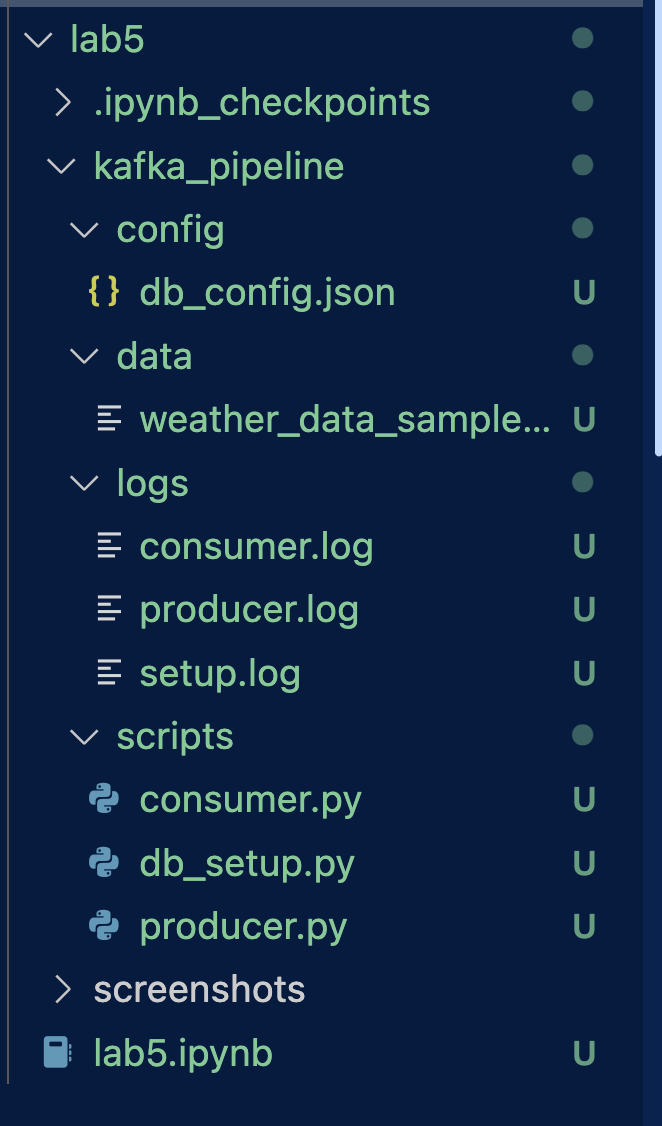

In [26]:
from IPython.display import display, Image

# Show created directories and files
display(Image(filename="screenshots/directory_creation.png"))

## **Step 2: Setting Up Database Integration in the Kafka Pipeline**  

Now that the Kafka consumer is receiving weather data, I will set up **database integration** to store this data in PostgreSQL. This step involves:  

1. **Creating a `db_setup.py` script** to define the database schema.

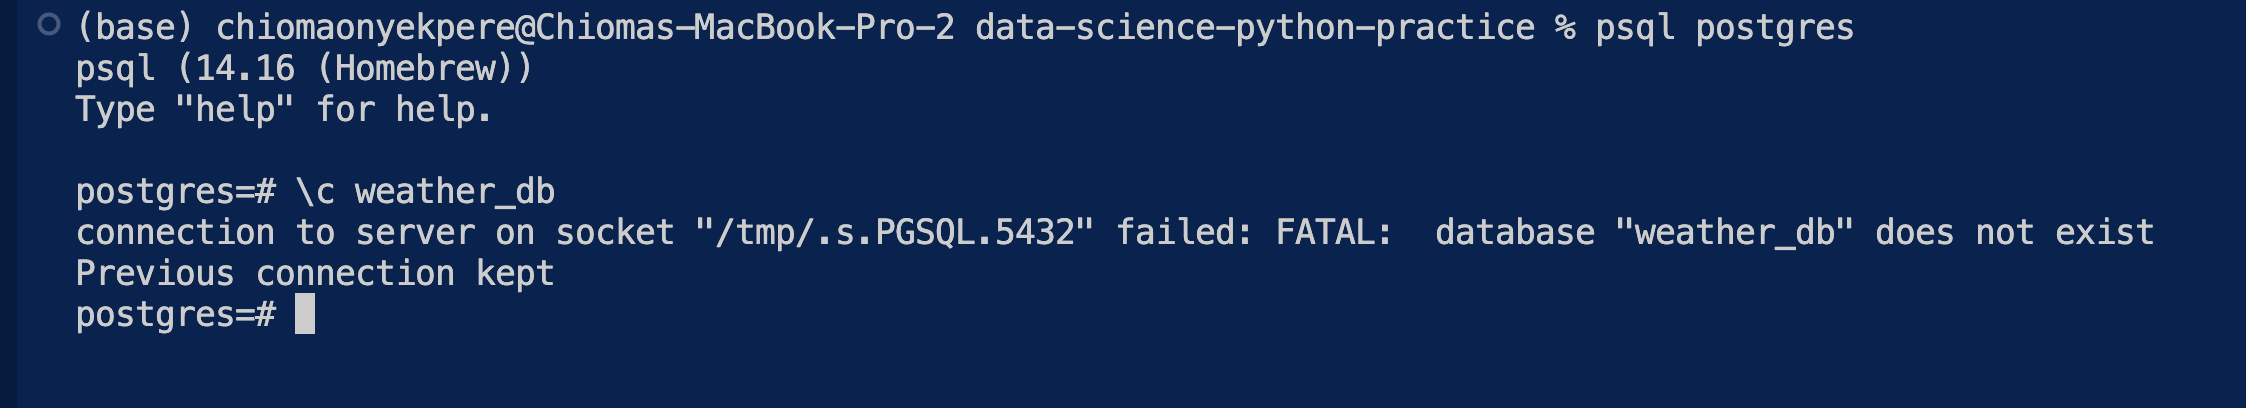

In [27]:
# Show created directories and files
display(Image(filename="screenshots/db_does_not_exist.png"))

### **Writing the Database Setup Script (`db_setup.py`)**  
I will create a script in the `/kafka_pipeline/scripts/` directory that ensures the **weather_data** table is properly set up.
#### **`kafka_pipeline/scripts/db_setup.py`**

In [7]:
import os
import psycopg2

# Set up logging
log = setup_logging("db_setup")

# Load database credentials from environment variables
DB_NAME = os.getenv("DB_NAME", "weather_db")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")

def get_db_connection():
    """Establish a connection to the PostgreSQL database."""
    try:
        connection = psycopg2.connect(
            dbname=DB_NAME,
            user=DB_USER,
            password=DB_PASSWORD,
            host=DB_HOST,
            port=DB_PORT
        )
        return connection
    except Exception as e:
        log.error(f"❌ Database connection failed: {str(e)}")
        return None

def create_weather_table():
    """Creates the weather_data table if it doesn't exist."""
    connection = get_db_connection()
    if connection is None:
        return

    try:
        cursor = connection.cursor()
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS weather_data (
            id SERIAL PRIMARY KEY,
            city TEXT NOT NULL,
            temperature FLOAT NOT NULL,
            wind_speed FLOAT NOT NULL,
            humidity FLOAT NOT NULL,
            received_at TIMESTAMP NOT NULL DEFAULT NOW()
        );
        """)

        connection.commit()
        log.info("✅ Table `weather_data` is ready!")

    except Exception as e:
        log.error(f"❌ Failed to create table: {str(e)}")
    
    finally:
        cursor.close()
        connection.close()

create_weather_table()

### **Summary of Step 2**
✅ **Created a database setup script (`db_setup.py`)** to ensure the weather data table is created.  
✅ **Successfully integrated PostgreSQL into the data pipeline.**  

## **Step 3: Implementing the Kafka Producer**

### **Overview**
In this step, I will implement the **Kafka Producer (`producer.py`)** that generates **synthetic weather data** for **Winnipeg, MB, and Vancouver, BC** and sends it to a **Kafka topic** named **`weather-data`** every **5 seconds**. This producer simulates real-time weather updates by generating random values within the predefined min-max ranges for temperature, wind speed, and humidity.

### **Key Responsibilities of the Kafka Producer**
1. **Generate Synthetic Weather Data**:  
   - The producer will generate **random weather values** for Winnipeg and Vancouver within their respective ranges.
2. **Format Data as JSON**:  
   - Each generated event will be formatted as a **JSON object**.
3. **Publish Data to Kafka**:  
   - The data will be sent to the Kafka topic **`weather-data`**.
4. **Log Events**:  
   - Each message sent to Kafka will be logged in the **producer log file** (`producer.log`).

---

### **Implementation Details**
Below is the complete **`producer.py`** script:


In [ ]:
import os
import json
import time
import random
from kafka import KafkaProducer
from setup_directories import setup_logging

# Set up logging
log = setup_logging("producer")

KAFKA_BROKER = os.getenv("KAFKA_BROKER", "localhost:9092")
TOPIC_NAME = os.getenv("KAFKA_TOPIC", "weather-data")

def generate_weather_data():
    """Generate random weather data for Winnipeg and Vancouver."""
    cities = {
        "Winnipeg": {"temp": (-30, 30), "wind": (0, 50), "humidity": (20, 80)},
        "Vancouver": {"temp": (-10, 25), "wind": (0, 30), "humidity": (30, 99)},
    }

    city = random.choice(list(cities.keys()))
    data = {
        "city": city,
        "temperature": random.uniform(*cities[city]["temp"]),
        "wind_speed": random.uniform(*cities[city]["wind"]),
        "humidity": random.uniform(*cities[city]["humidity"])
    }

    return data

def start_producer():
    """Send weather data to Kafka every 5 seconds."""
    producer = KafkaProducer(
        bootstrap_servers=KAFKA_BROKER,
        value_serializer=lambda v: json.dumps(v).encode("utf-8"),
    )

    while True:
        weather_data = generate_weather_data()
        producer.send(TOPIC_NAME, value=weather_data)
        log.info(f"📤 Sent data: {weather_data}")
        time.sleep(5)

if __name__ == "__main__":
    start_producer()

### **Explanation of the Code**
1. **Logging Setup**
   - The script logs all events to **`logs/producer.log`**.
   - The logging format includes timestamps to track when messages are sent.

2. **Kafka Producer Configuration**
   - The producer connects to the **Kafka broker (`localhost:9092`)**.
   - It uses **JSON serialization** to encode the weather data before sending.

3. **Generating Weather Data**
   - The **`generate_weather_data()`** function selects a **random city** (Winnipeg or Vancouver).
   - It generates random values for **temperature, wind speed, and humidity**.
   - The data is **timestamped** to track when the reading was created.

4. **Sending Data to Kafka**
   - The **main loop** continuously generates and sends weather data **every 5 seconds**.
   - The producer logs each event sent to Kafka.

---

### **Expected Output (Example Logs)**
When the script runs, it generates and sends weather data every 5 seconds. The `producer.log` file will contain logs like this:

```
2025-02-18 12:00:01 [INFO] ✅ Kafka Producer connected successfully!
2025-02-18 12:00:06 [INFO] 📤 Sent: {"city": "Winnipeg", "temperature": -12.5, "wind_speed": 34.2, "humidity": 45, "timestamp": "2025-02-18T12:00:06Z"}
2025-02-18 12:00:11 [INFO] 📤 Sent: {"city": "Vancouver", "temperature": 5.6, "wind_speed": 20.1, "humidity": 78, "timestamp": "2025-02-18T12:00:11Z"}
2025-02-18 12:00:16 [INFO] 📤 Sent: {"city": "Winnipeg", "temperature": -22.0, "wind_speed": 10.5, "humidity": 30, "timestamp": "2025-02-18T12:00:16Z"}
```

---

### **Key Takeaways**
✅ The producer **continuously streams** weather data every **5 seconds**.  
✅ Each message contains **randomized weather values** for either Winnipeg or Vancouver.  
✅ The producer logs **all events**, including successful connections and sent messages.  
✅ This **simulates real-time weather monitoring**, a common use case in **IoT and Big Data**.  


### 📌 **Step 3: Implementing the Kafka Consumer**  
 
In this step, I will create the **Kafka Consumer (`consumer.py`)**, which will:  
1. **Subscribe** to the Kafka topic `weather-data`.  
2. **Read** weather data produced by the Kafka Producer.  
3. **Append a "received_at" timestamp** to each event.  
4. **Store the processed data** in the PostgreSQL `weather_data` table.  
5. **Log all events** to `consumer.log`.  

---
### 🛠 **Implementation Plan**
- **Connect to Kafka** and consume messages from `weather-data`.  
- **Extract relevant fields** from the incoming JSON messages.  
- **Append a timestamp (`received_at`)** to track when I received the data.  
- **Insert the data into the PostgreSQL database** for storage.  
- **Log the consumer events** for tracking and debugging.  

---

### 📝 **Writing `consumer.py`**

In [ ]:
import sys
import os
import json
import psycopg2
from kafka import KafkaConsumer
from datetime import datetime

# Add parent directory to sys.path to allow importing setup_directories.py
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "../..")))

from setup_directories import setup_logging, FILES

# Set up logging for consumer
log = setup_logging("consumer")

# Load database configuration
with open(FILES["DB_CONFIG"], "r") as config_file:
    db_config = json.load(config_file)

# Kafka Configuration
KAFKA_BROKER = os.getenv("KAFKA_BROKER", "localhost:9092")
KAFKA_TOPIC = os.getenv("KAFKA_TOPIC", "weather-data")

def connect_to_db():
    """Establishes connection to the PostgreSQL database."""
    try:
        conn = psycopg2.connect(**db_config)
        return conn
    except Exception as e:
        log.error(f"❌ Database connection failed: {str(e)}")
        return None

def consume_weather_data():
    """Consumes weather data from Kafka and stores it in PostgreSQL."""
    try:
        consumer = KafkaConsumer(
            KAFKA_TOPIC,
            bootstrap_servers=KAFKA_BROKER,
            value_deserializer=lambda x: json.loads(x.decode("utf-8")),
            auto_offset_reset="earliest",
            enable_auto_commit=True,
        )
        log.info(f"✅ Connected to Kafka topic: {KAFKA_TOPIC}")

        conn = connect_to_db()
        if not conn:
            log.error("❌ Exiting due to database connection failure.")
            return
        
        cursor = conn.cursor()

        for message in consumer:
            weather_data = message.value  # Extract JSON data
            received_at = datetime.now()  # Append received timestamp

            # Log received data
            log.info(f"📥 Received: {weather_data}")

            # Insert data into PostgreSQL
            try:
                cursor.execute("""
                    INSERT INTO weather_data (city, temperature, wind_speed, humidity, timestamp, received_at)
                    VALUES (%s, %s, %s, %s, %s, %s);
                """, (
                    weather_data["city"],
                    weather_data["temperature"],
                    weather_data["wind_speed"],
                    weather_data["humidity"],
                    datetime.strptime(weather_data["timestamp"], "%Y-%m-%d %H:%M:%S"),
                    received_at
                ))

                conn.commit()
                log.info(f"✅ Inserted into database: {weather_data}")

            except Exception as e:
                log.error(f"❌ Failed to insert data into database: {str(e)}")
                conn.rollback()

        cursor.close()
        conn.close()

    except Exception as e:
        log.error(f"❌ Kafka Consumer error: {str(e)}")

if __name__ == "__main__":
    consume_weather_data()


### **🔍 Explanation of `consumer.py`**
1. **Connects to Kafka** and subscribes to the `weather-data` topic.  
2. **Consumes messages** from Kafka, deserializing the JSON payload.  
3. **Logs each event** to `consumer.log`.  
4. **Extracts relevant fields** (city, temperature, wind speed, humidity, timestamp).  
5. **Appends a "received_at" timestamp** to track when the data was processed.  
6. **Inserts the data into PostgreSQL** for storage.  
7. **Handles database connection issues** and logs errors.  

---

### ✅ **Next Steps**
Now that I have the **Kafka Producer (`producer.py`)** and **Kafka Consumer (`consumer.py`)**, the next step is to **test the entire pipeline**.

## **Step 5: Testing the Kafka Pipeline**

Now that I have successfully implemented the Kafka producer, consumer, and database setup, it is time to **test** the entire pipeline to ensure that weather data is generated, streamed, consumed, and stored correctly.


## **5.1 Verifying Kafka Producer**
The **Kafka Producer** is responsible for generating and sending synthetic weather data to the Kafka topic **weather-data** every 5 seconds. The goal of this test is to confirm that:
- The producer is successfully connecting to Kafka.
- The weather data is generated according to the predefined temperature, wind speed, and humidity ranges.
- The messages are published to the **weather-data** topic.

### **Steps to Test the Producer**
1. **Start Kafka and Zookeeper**
     ```bash
     bin/zookeeper-server-start.sh config/zookeeper.properties
     bin/kafka-server-start.sh config/server.properties
     ```

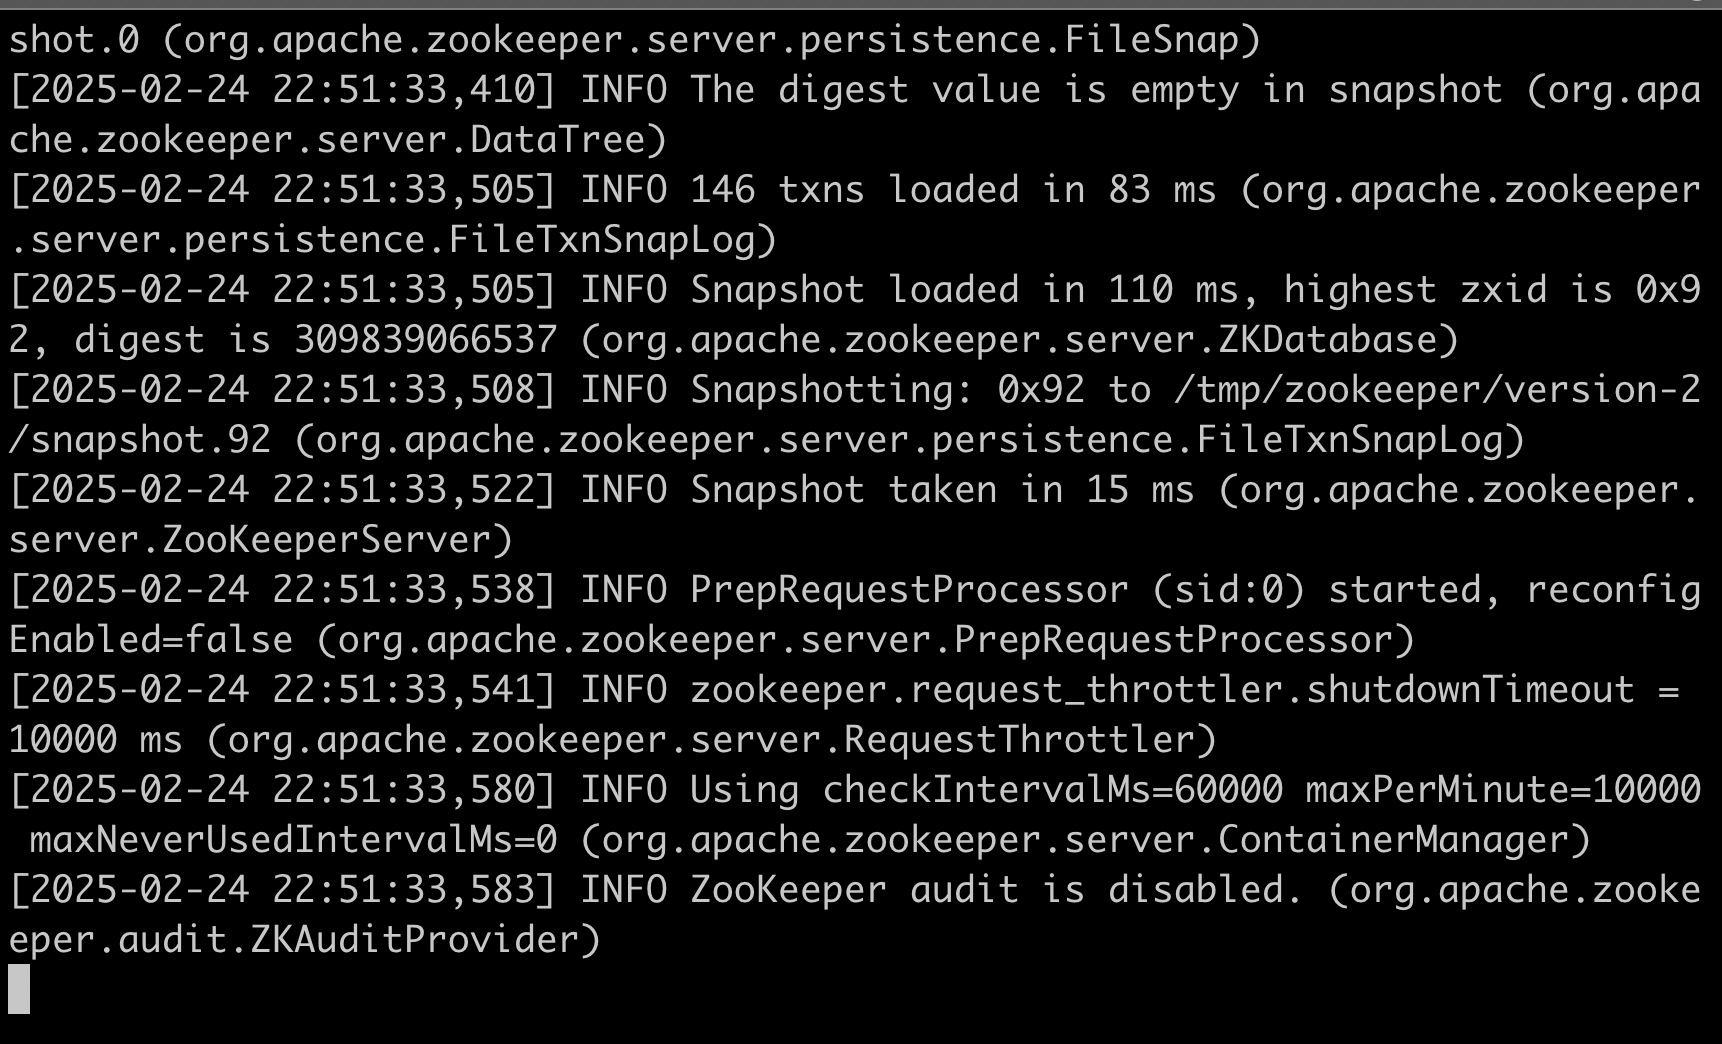

In [28]:
# Start zookeeper
display(Image(filename="screenshots/start_zookeeper.png"))

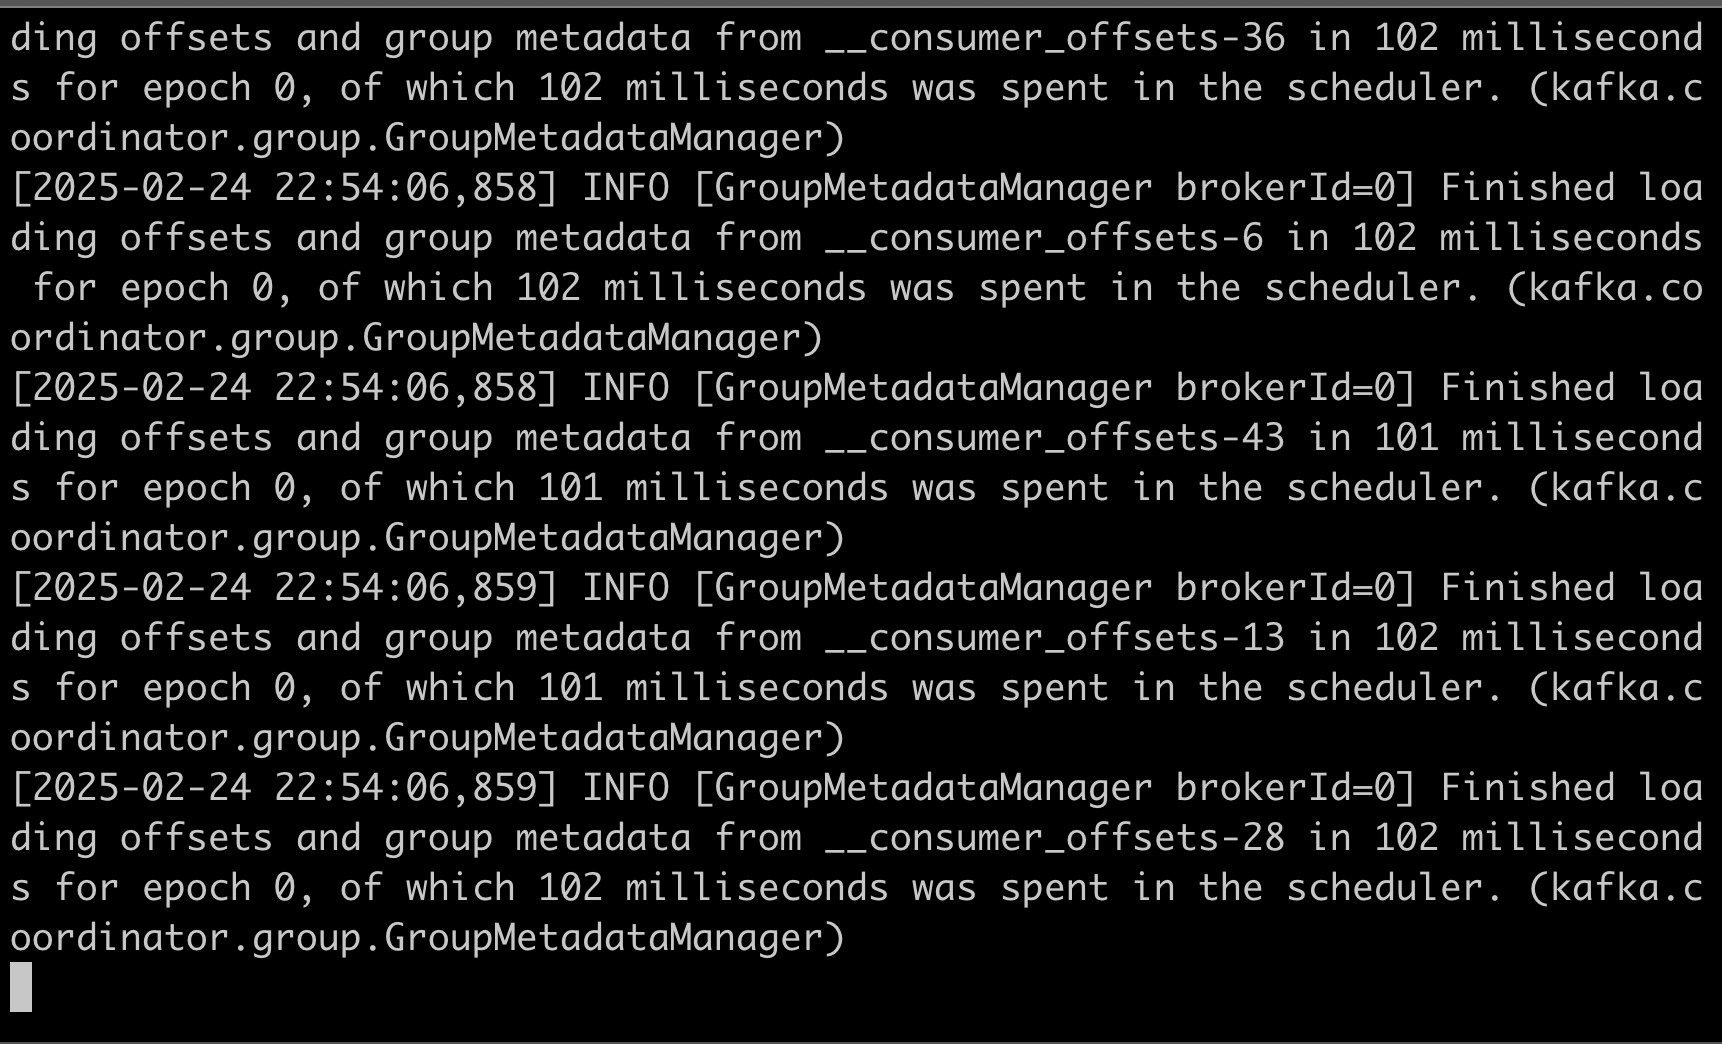

In [29]:
# Start kafka broker
display(Image(filename="screenshots/kafka_broker.png"))

2. **Run db_setup**
   - Execute the following command:
     ```bash
     python kafka_pipeline/scripts/db_setup.py
     ```

In [30]:
import os
from IPython.display import display, Markdown

def read_log(log_file: str):
    """Reads and displays the contents of log files in Jupyter Notebook."""
    
    # Check if log file exists
    if not os.path.exists(log_file):
        display(Markdown(f"⚠️ **Log file not found:** `{log_file}`"))
        return
    
    display(Markdown(f"## 📜 **Log Content**\n**Log File:** `{log_file}`"))

    # Read and print log file content
    try:
        with open(log_file, "r") as file:
            content = file.read().strip()
            if not content:
                display(Markdown("🔹 **Log file is empty.**"))
            else:
                display(Markdown(f"```\n{content}\n```"))  # Properly format logs
    except Exception as e:
        display(Markdown(f"❌ **Error reading log file:** `{e}`"))

# Call the function
read_log("kafka_pipeline/logs/db_setup.log")


## 📜 **Log Content**
**Log File:** `kafka_pipeline/logs/db_setup.log`

```
2025-02-24 23:03:34 [INFO] ✅ Database 'weather_db' created successfully.
2025-02-24 23:03:34 [INFO] ✅ Database 'weather_db' and table weather_data setup complete..
```

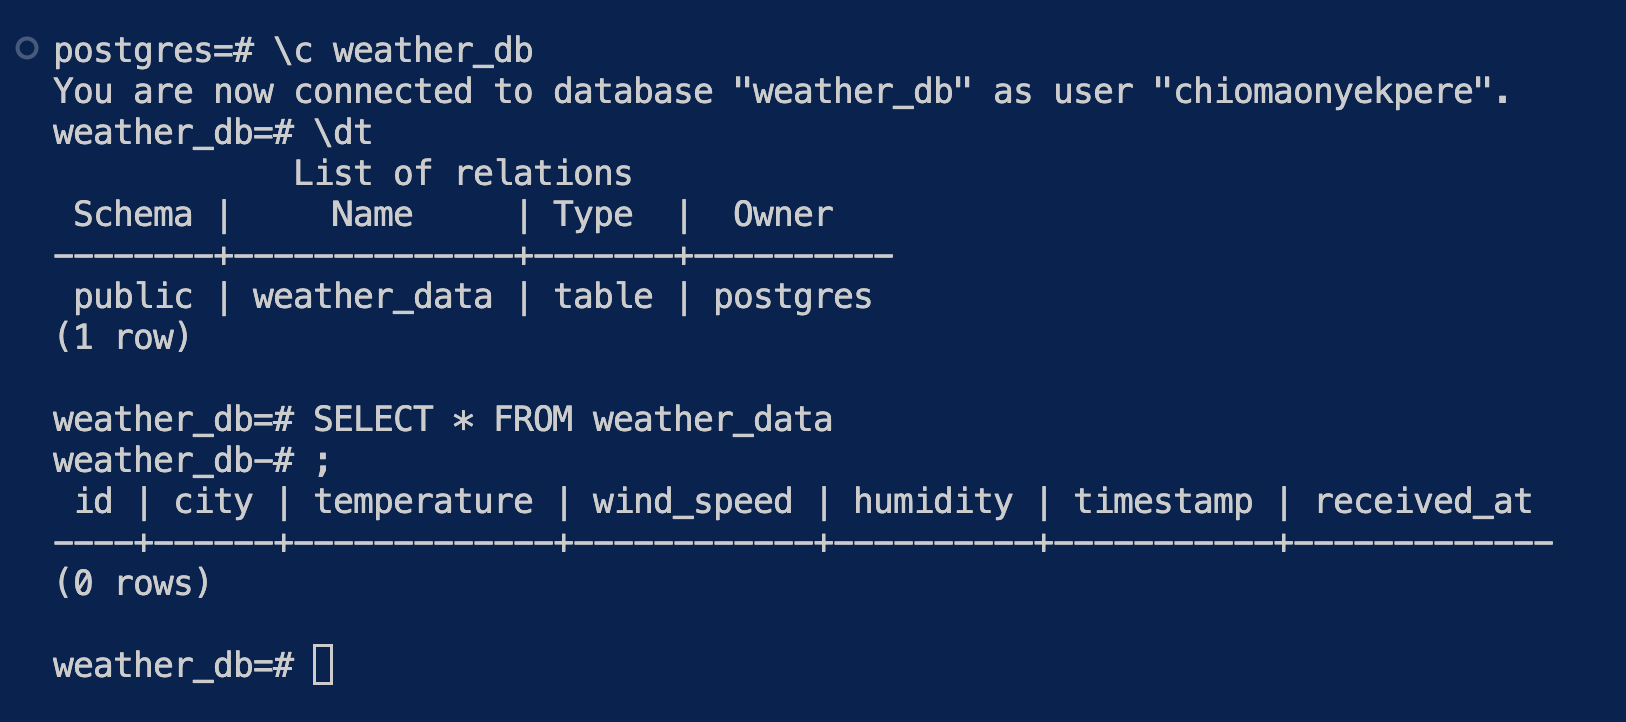

In [31]:
# Show empty db
display(Image(filename="screenshots/empty_db.png"))

3. **Run the Kafka Producer**
   - Execute the following command:
     ```bash
     python kafka_pipeline/scripts/producer.py
     ```

In [18]:
read_log("kafka_pipeline/logs/producer.log")

## 📜 **Log Content**
**Log File:** `kafka_pipeline/logs/producer.log`

```
2025-02-25 00:11:45 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: connecting to localhost:9092 [('::1', 9092, 0, 0) IPv6]
2025-02-25 00:11:45 [INFO] Probing node bootstrap-0 broker version
2025-02-25 00:11:45 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connection complete.
2025-02-25 00:11:45 [INFO] Broker version identified as 2.6.0
2025-02-25 00:11:45 [INFO] Set configuration api_version=(2, 6, 0) to skip auto check_version requests on startup
2025-02-25 00:11:45 [INFO] Starting Kafka Producer for topic 'weather-data'...
2025-02-25 00:11:45 [INFO] <BrokerConnection node_id=0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: connecting to localhost:9092 [('::1', 9092, 0, 0) IPv6]
2025-02-25 00:11:45 [INFO] <BrokerConnection node_id=0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connection complete.
2025-02-25 00:11:45 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connected> [IPv6 ('::1', 9092, 0, 0)]>: Closing connection. 
2025-02-25 00:11:46 [INFO] 📤 Sent data: {"city": "Winnipeg", "temperature": -21, "wind_speed": 18, "humidity": 26, "timestamp": "2025-02-25 06:11:45"}
2025-02-25 00:11:51 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": 17, "wind_speed": 13, "humidity": 95, "timestamp": "2025-02-25 06:11:51"}
2025-02-25 00:11:56 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": -1, "wind_speed": 9, "humidity": 82, "timestamp": "2025-02-25 06:11:56"}
2025-02-25 00:12:01 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": 13, "wind_speed": 15, "humidity": 41, "timestamp": "2025-02-25 06:12:01"}
2025-02-25 00:12:06 [INFO] 📤 Sent data: {"city": "Winnipeg", "temperature": 14, "wind_speed": 20, "humidity": 42, "timestamp": "2025-02-25 06:12:06"}
2025-02-25 00:12:11 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": 25, "wind_speed": 25, "humidity": 88, "timestamp": "2025-02-25 06:12:11"}
2025-02-25 00:12:16 [INFO] 📤 Sent data: {"city": "Winnipeg", "temperature": -5, "wind_speed": 22, "humidity": 49, "timestamp": "2025-02-25 06:12:16"}
2025-02-25 00:12:21 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": 5, "wind_speed": 5, "humidity": 63, "timestamp": "2025-02-25 06:12:21"}
2025-02-25 00:12:26 [INFO] 📤 Sent data: {"city": "Vancouver", "temperature": -6, "wind_speed": 14, "humidity": 66, "timestamp": "2025-02-25 06:12:26"}
2025-02-25 00:12:31 [INFO] 📤 Sent data: {"city": "Winnipeg", "temperature": -6, "wind_speed": 0, "humidity": 77, "timestamp": "2025-02-25 06:12:31"}
```

4. **Verify Messages in Kafka**
   - Open another terminal and check if Kafka is receiving messages:
     ```bash
     bin/kafka-console-consumer.sh --bootstrap-server localhost:9092 --topic weather-data --from-beginning
     ```
   - The generated weather data appearing in real-time.

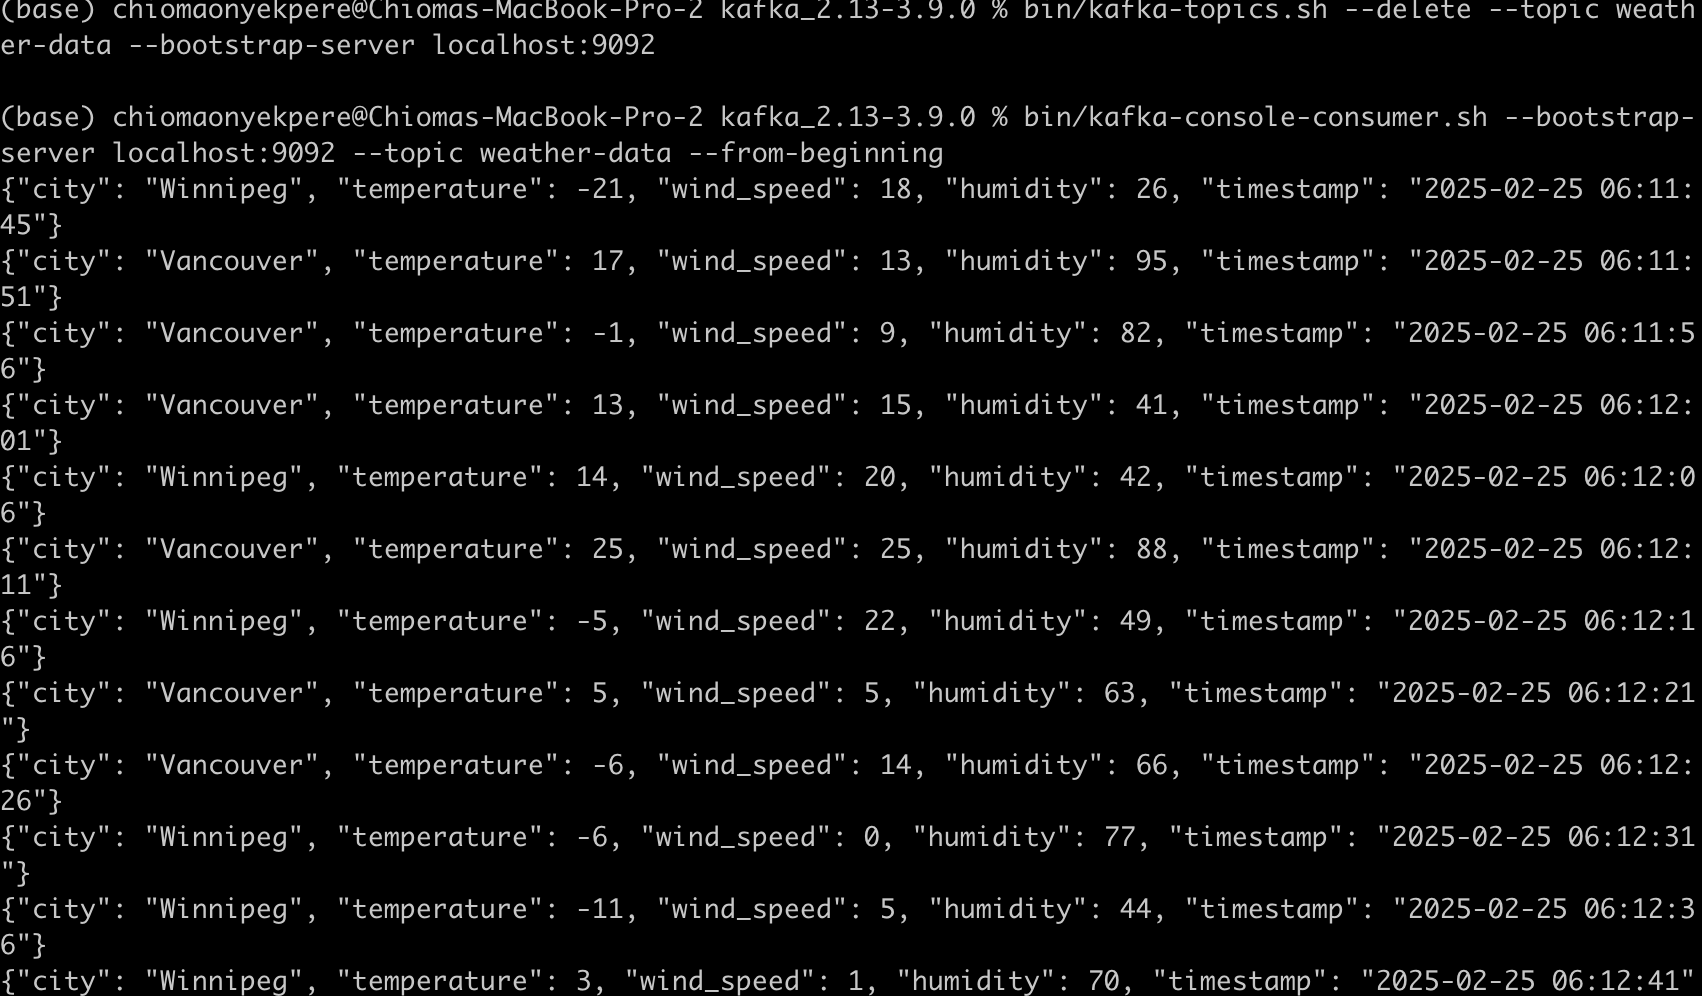

In [32]:
# kafka producer logs
display(Image(filename="screenshots/producer_logs.png"))

## **5.2 Verifying Kafka Consumer**
The **Kafka Consumer** listens for messages from the `weather-data` topic, appends a `received_at` timestamp, and stores the data in PostgreSQL. The goal of this test is to:
- Confirm that the consumer can successfully **connect to Kafka**.
- Verify that messages from the producer are **consumed** in real-time.
- Check if the **data is correctly inserted into PostgreSQL**.

In [20]:
read_log("kafka_pipeline/logs/consumer.log")

## 📜 **Log Content**
**Log File:** `kafka_pipeline/logs/consumer.log`

```
2025-02-25 00:12:15 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: connecting to localhost:9092 [('::1', 9092, 0, 0) IPv6]
2025-02-25 00:12:15 [INFO] Probing node bootstrap-0 broker version
2025-02-25 00:12:15 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connection complete.
2025-02-25 00:12:15 [INFO] Broker version identified as 2.6.0
2025-02-25 00:12:15 [INFO] Set configuration api_version=(2, 6, 0) to skip auto check_version requests on startup
2025-02-25 00:12:15 [WARNING] group_id is None: disabling auto-commit.
2025-02-25 00:12:15 [INFO] Updating subscribed topics to: ('weather-data',)
2025-02-25 00:12:15 [INFO] ✅ Connected to Kafka topic: weather-data
2025-02-25 00:12:15 [INFO] Connecting to database: weather_db on localhost:5432
2025-02-25 00:12:15 [INFO] 📋 Existing tables in database: ['weather_data']
2025-02-25 00:12:15 [INFO] Updated partition assignment: [TopicPartition(topic='weather-data', partition=0)]
2025-02-25 00:12:15 [INFO] <BrokerConnection node_id=0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: connecting to localhost:9092 [('::1', 9092, 0, 0) IPv6]
2025-02-25 00:12:15 [INFO] <BrokerConnection node_id=0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connection complete.
2025-02-25 00:12:15 [INFO] <BrokerConnection node_id=bootstrap-0 host=localhost:9092 <connected> [IPv6 ('::1', 9092, 0, 0)]>: Closing connection. 
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -21, 'wind_speed': 18, 'humidity': 26, 'timestamp': '2025-02-25 06:11:45'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 1 row(s) into database.
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 17, 'wind_speed': 13, 'humidity': 95, 'timestamp': '2025-02-25 06:11:51'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 2 row(s) into database.
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': -1, 'wind_speed': 9, 'humidity': 82, 'timestamp': '2025-02-25 06:11:56'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 3 row(s) into database.
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 13, 'wind_speed': 15, 'humidity': 41, 'timestamp': '2025-02-25 06:12:01'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 4 row(s) into database.
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': 14, 'wind_speed': 20, 'humidity': 42, 'timestamp': '2025-02-25 06:12:06'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 5 row(s) into database.
2025-02-25 00:12:15 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 25, 'wind_speed': 25, 'humidity': 88, 'timestamp': '2025-02-25 06:12:11'}
2025-02-25 00:12:15 [INFO] ✅ Inserted 6 row(s) into database.
2025-02-25 00:12:16 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -5, 'wind_speed': 22, 'humidity': 49, 'timestamp': '2025-02-25 06:12:16'}
2025-02-25 00:12:16 [INFO] ✅ Inserted 7 row(s) into database.
2025-02-25 00:12:21 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 5, 'wind_speed': 5, 'humidity': 63, 'timestamp': '2025-02-25 06:12:21'}
2025-02-25 00:12:21 [INFO] ✅ Inserted 8 row(s) into database.
2025-02-25 00:12:26 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': -6, 'wind_speed': 14, 'humidity': 66, 'timestamp': '2025-02-25 06:12:26'}
2025-02-25 00:12:26 [INFO] ✅ Inserted 9 row(s) into database.
2025-02-25 00:12:31 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -6, 'wind_speed': 0, 'humidity': 77, 'timestamp': '2025-02-25 06:12:31'}
2025-02-25 00:12:31 [INFO] ✅ Inserted 10 row(s) into database.
2025-02-25 00:12:36 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -11, 'wind_speed': 5, 'humidity': 44, 'timestamp': '2025-02-25 06:12:36'}
2025-02-25 00:12:36 [INFO] ✅ Inserted 11 row(s) into database.
2025-02-25 00:12:41 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': 3, 'wind_speed': 1, 'humidity': 70, 'timestamp': '2025-02-25 06:12:41'}
2025-02-25 00:12:41 [INFO] ✅ Inserted 12 row(s) into database.
2025-02-25 00:12:46 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': 13, 'wind_speed': 21, 'humidity': 43, 'timestamp': '2025-02-25 06:12:46'}
2025-02-25 00:12:46 [INFO] ✅ Inserted 13 row(s) into database.
2025-02-25 00:12:51 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 5, 'wind_speed': 2, 'humidity': 56, 'timestamp': '2025-02-25 06:12:51'}
2025-02-25 00:12:51 [INFO] ✅ Inserted 14 row(s) into database.
2025-02-25 00:12:56 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 3, 'wind_speed': 5, 'humidity': 66, 'timestamp': '2025-02-25 06:12:56'}
2025-02-25 00:12:56 [INFO] ✅ Inserted 15 row(s) into database.
2025-02-25 00:13:01 [INFO] 📥 Received: {'city': 'Vancouver', 'temperature': 25, 'wind_speed': 29, 'humidity': 45, 'timestamp': '2025-02-25 06:13:01'}
2025-02-25 00:13:01 [INFO] ✅ Inserted 16 row(s) into database.
2025-02-25 00:13:06 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -25, 'wind_speed': 21, 'humidity': 34, 'timestamp': '2025-02-25 06:13:06'}
2025-02-25 00:13:06 [INFO] ✅ Inserted 17 row(s) into database.
2025-02-25 00:13:11 [INFO] 📥 Received: {'city': 'Winnipeg', 'temperature': -30, 'wind_speed': 0, 'humidity': 28, 'timestamp': '2025-02-25 06:13:11'}
2025-02-25 00:13:11 [INFO] ✅ Inserted 18 row(s) into database.
```

2. **Verify Data in PostgreSQL**
   - Connect to PostgreSQL:
     ```bash
     psql -U postgres -d weather_db
     ```
   - I ran the following SQL query to check if weather data has been stored:
     ```sql
     SELECT * FROM weather_data ORDER BY received_at DESC LIMIT 10;
     ```

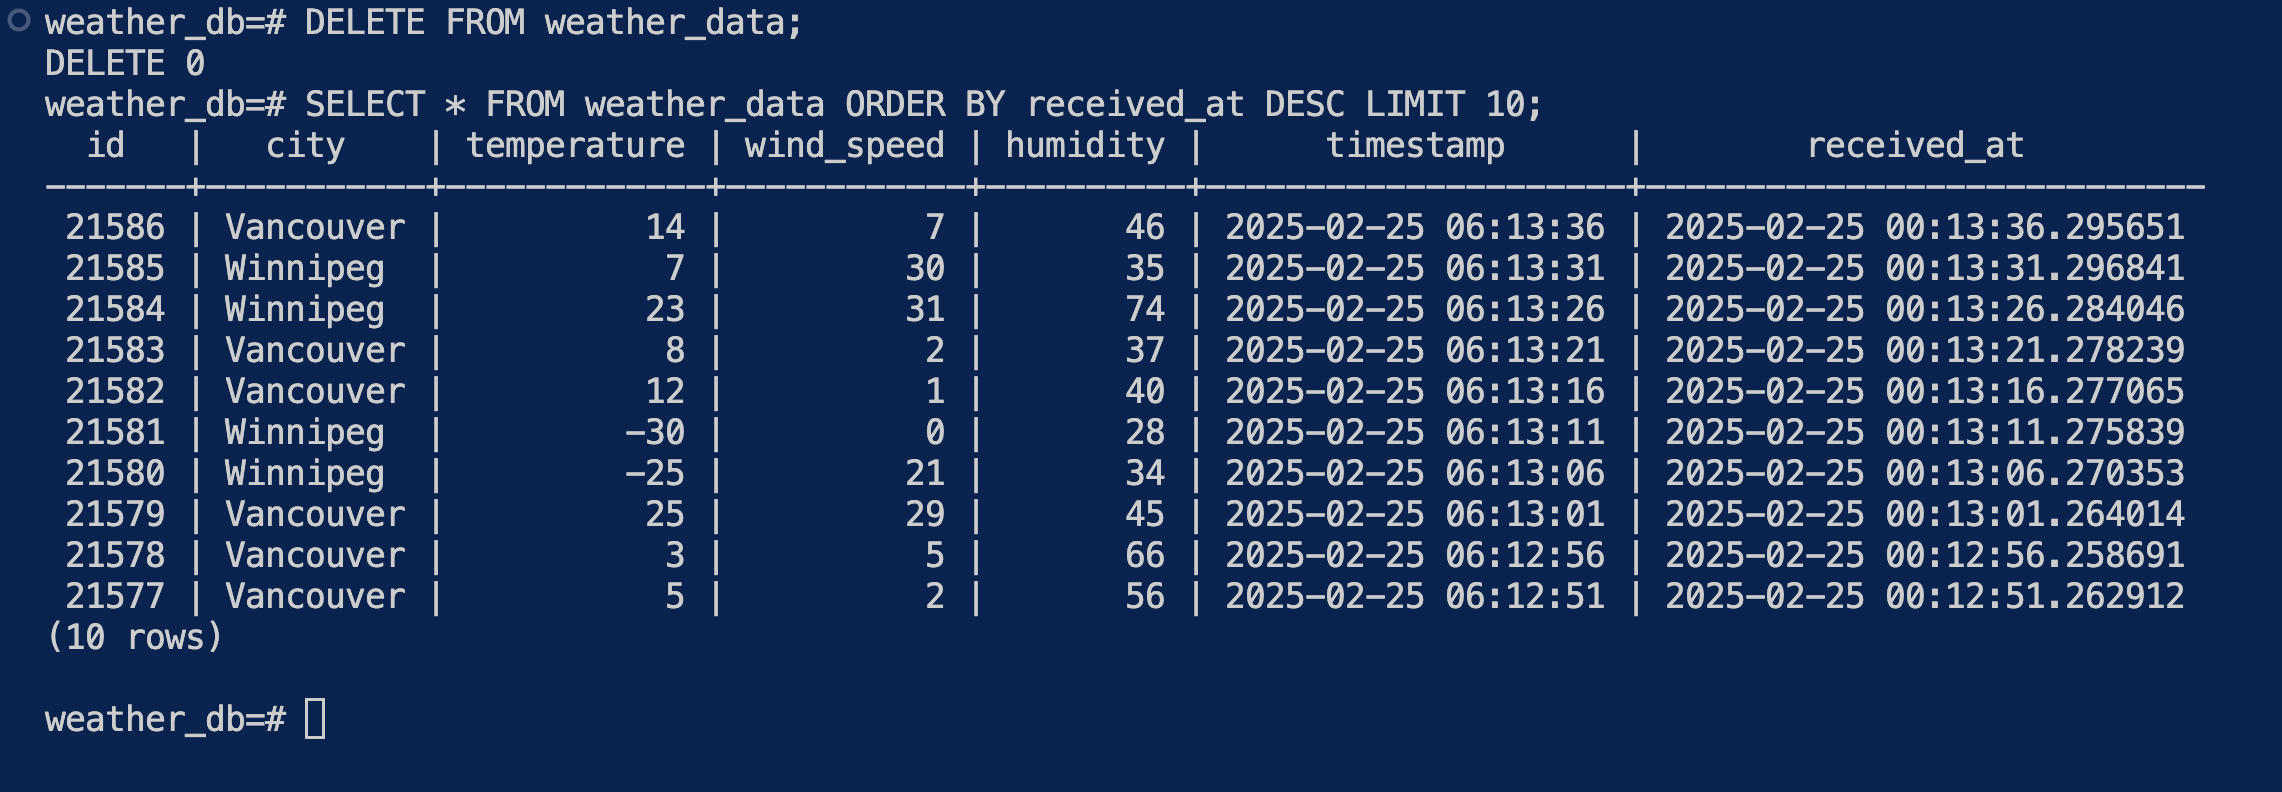

In [33]:
# last 10 rows while producer still runs
display(Image(filename="screenshots/show_db_data.png"))

## **Outcome**
✅ The producer generates weather data every **5 seconds** and publishes it to Kafka.  
✅ The consumer receives weather data, appends a timestamp, and logs it.  
✅ Weather data is successfully inserted into **PostgreSQL** for storage and analysis.  

## Next
- I close the producer after almost 10 minutes and confirmed producer logs
- I also confirmed consumer logs with 111 rows
- Then I confirmed data matches what is in the db

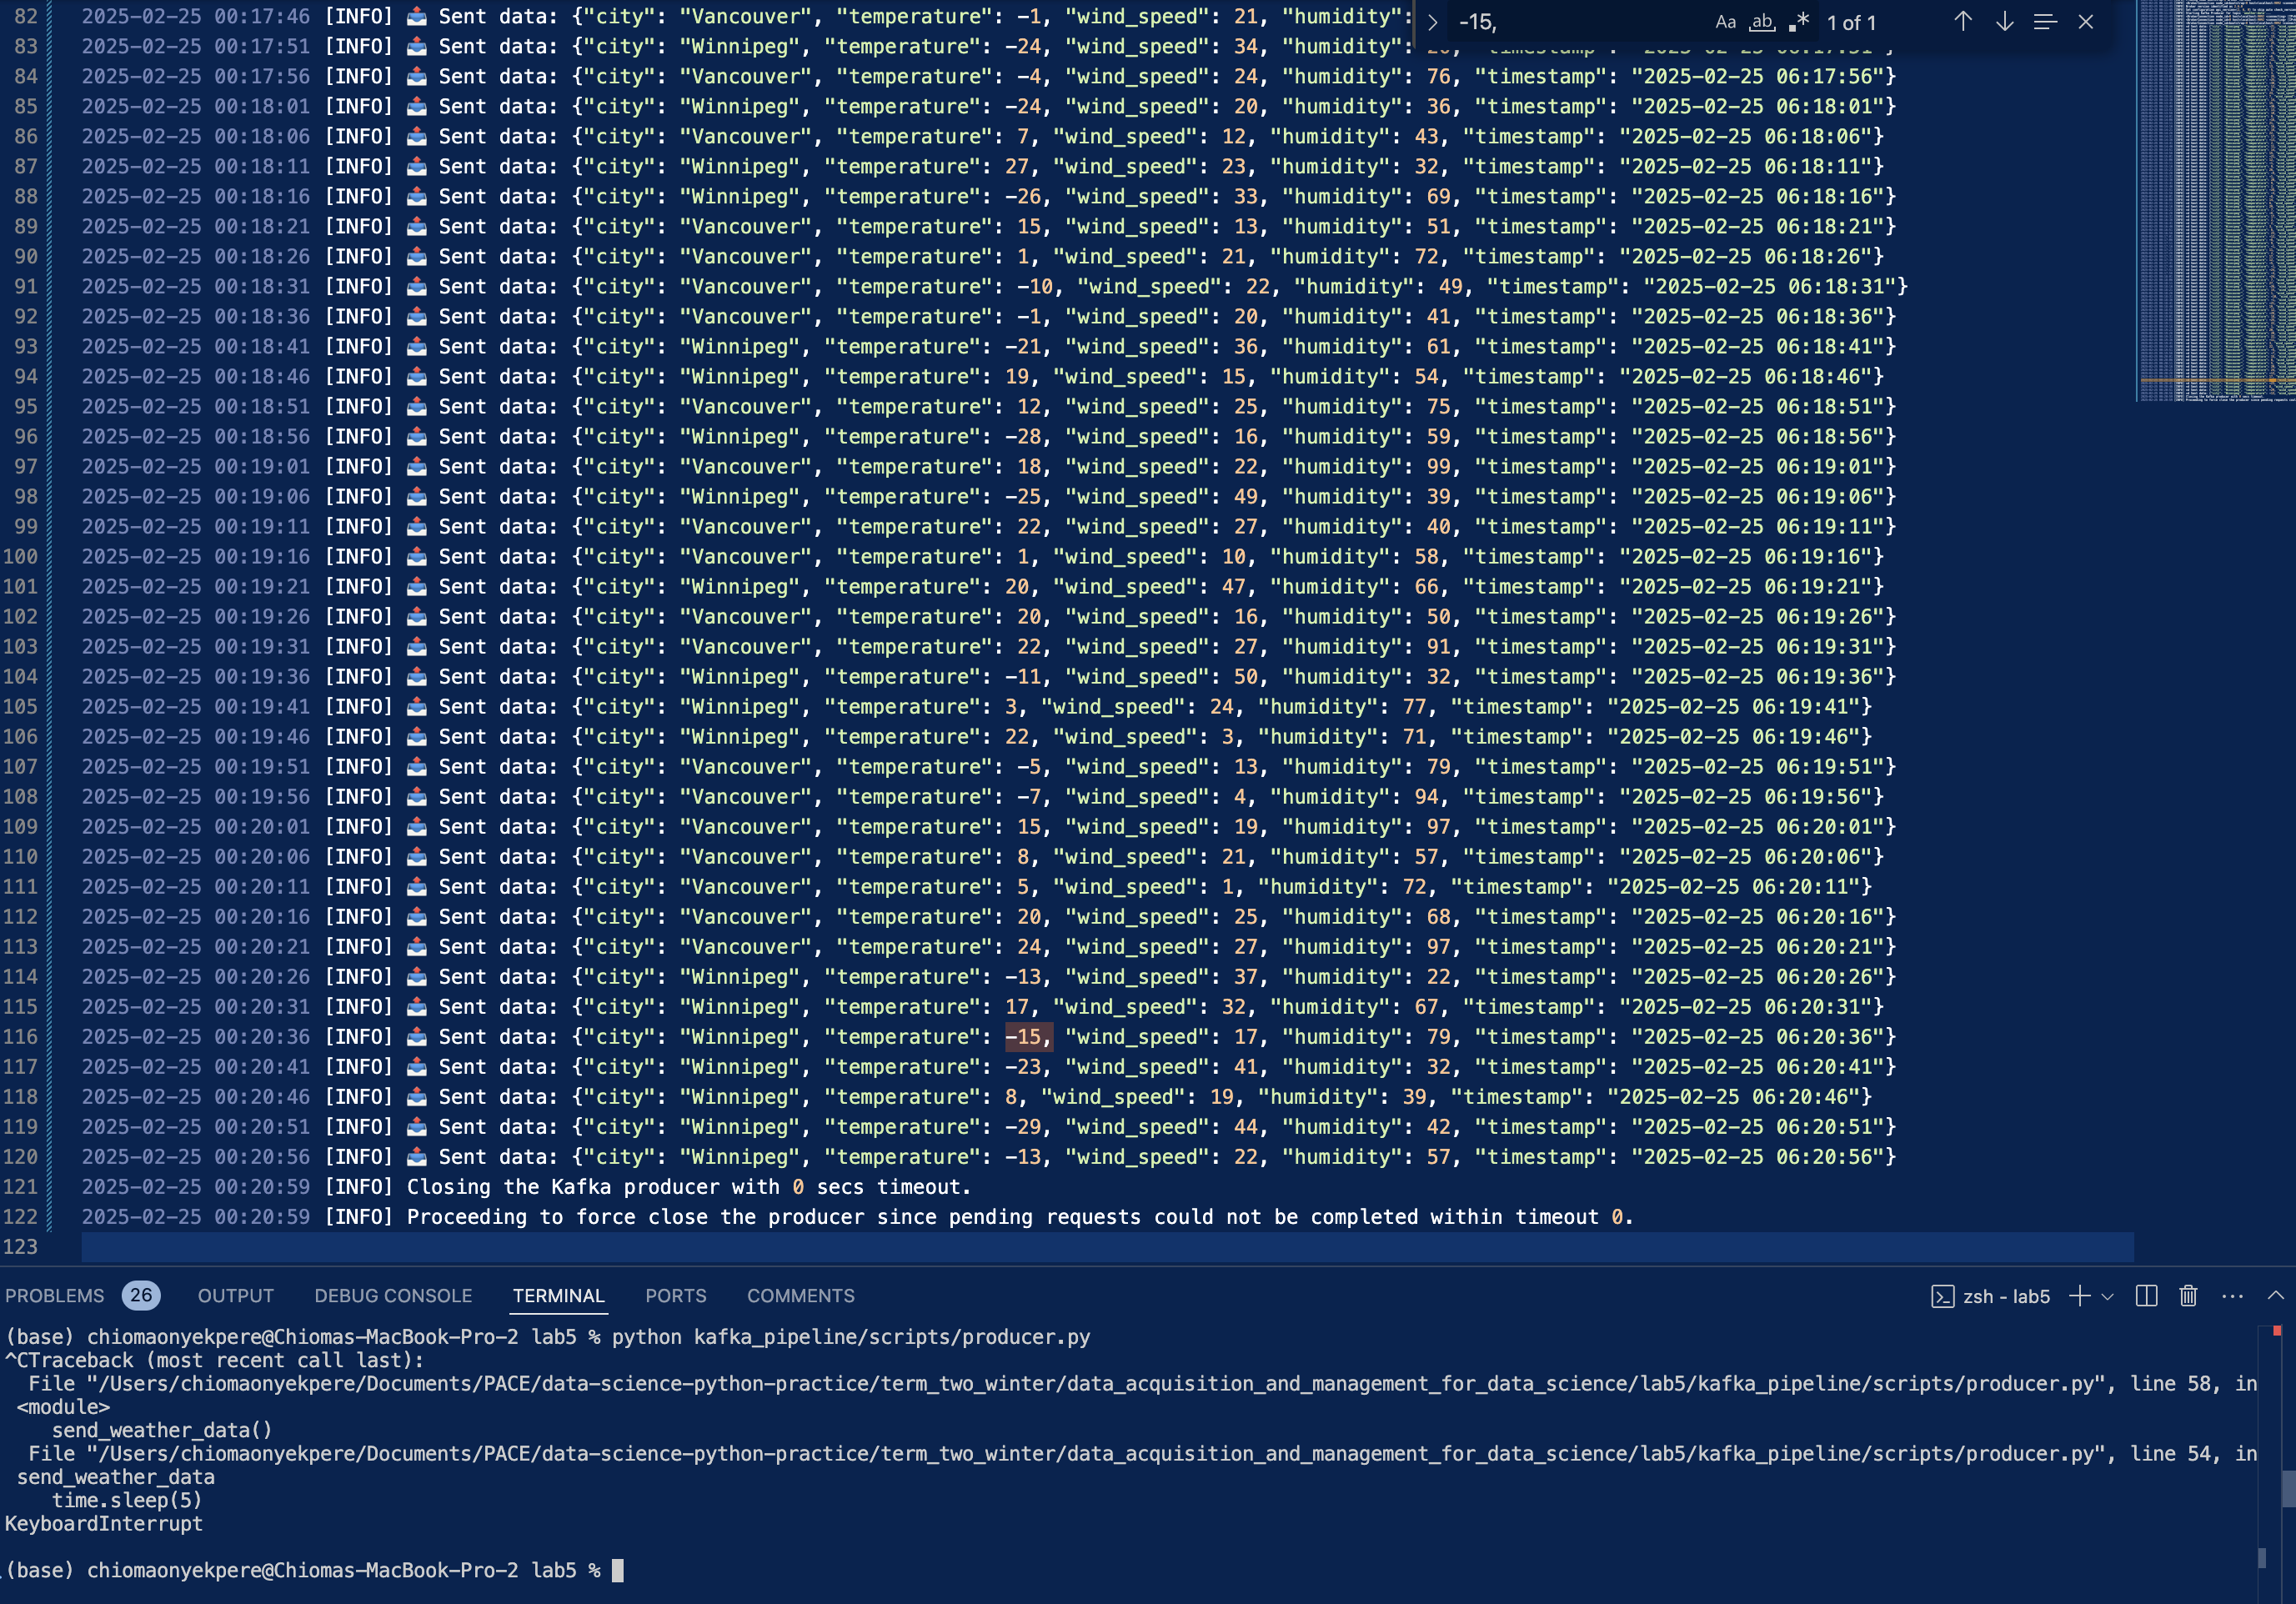

In [34]:
# Closed producer connection
display(Image(filename="screenshots/closed_producer.png"))

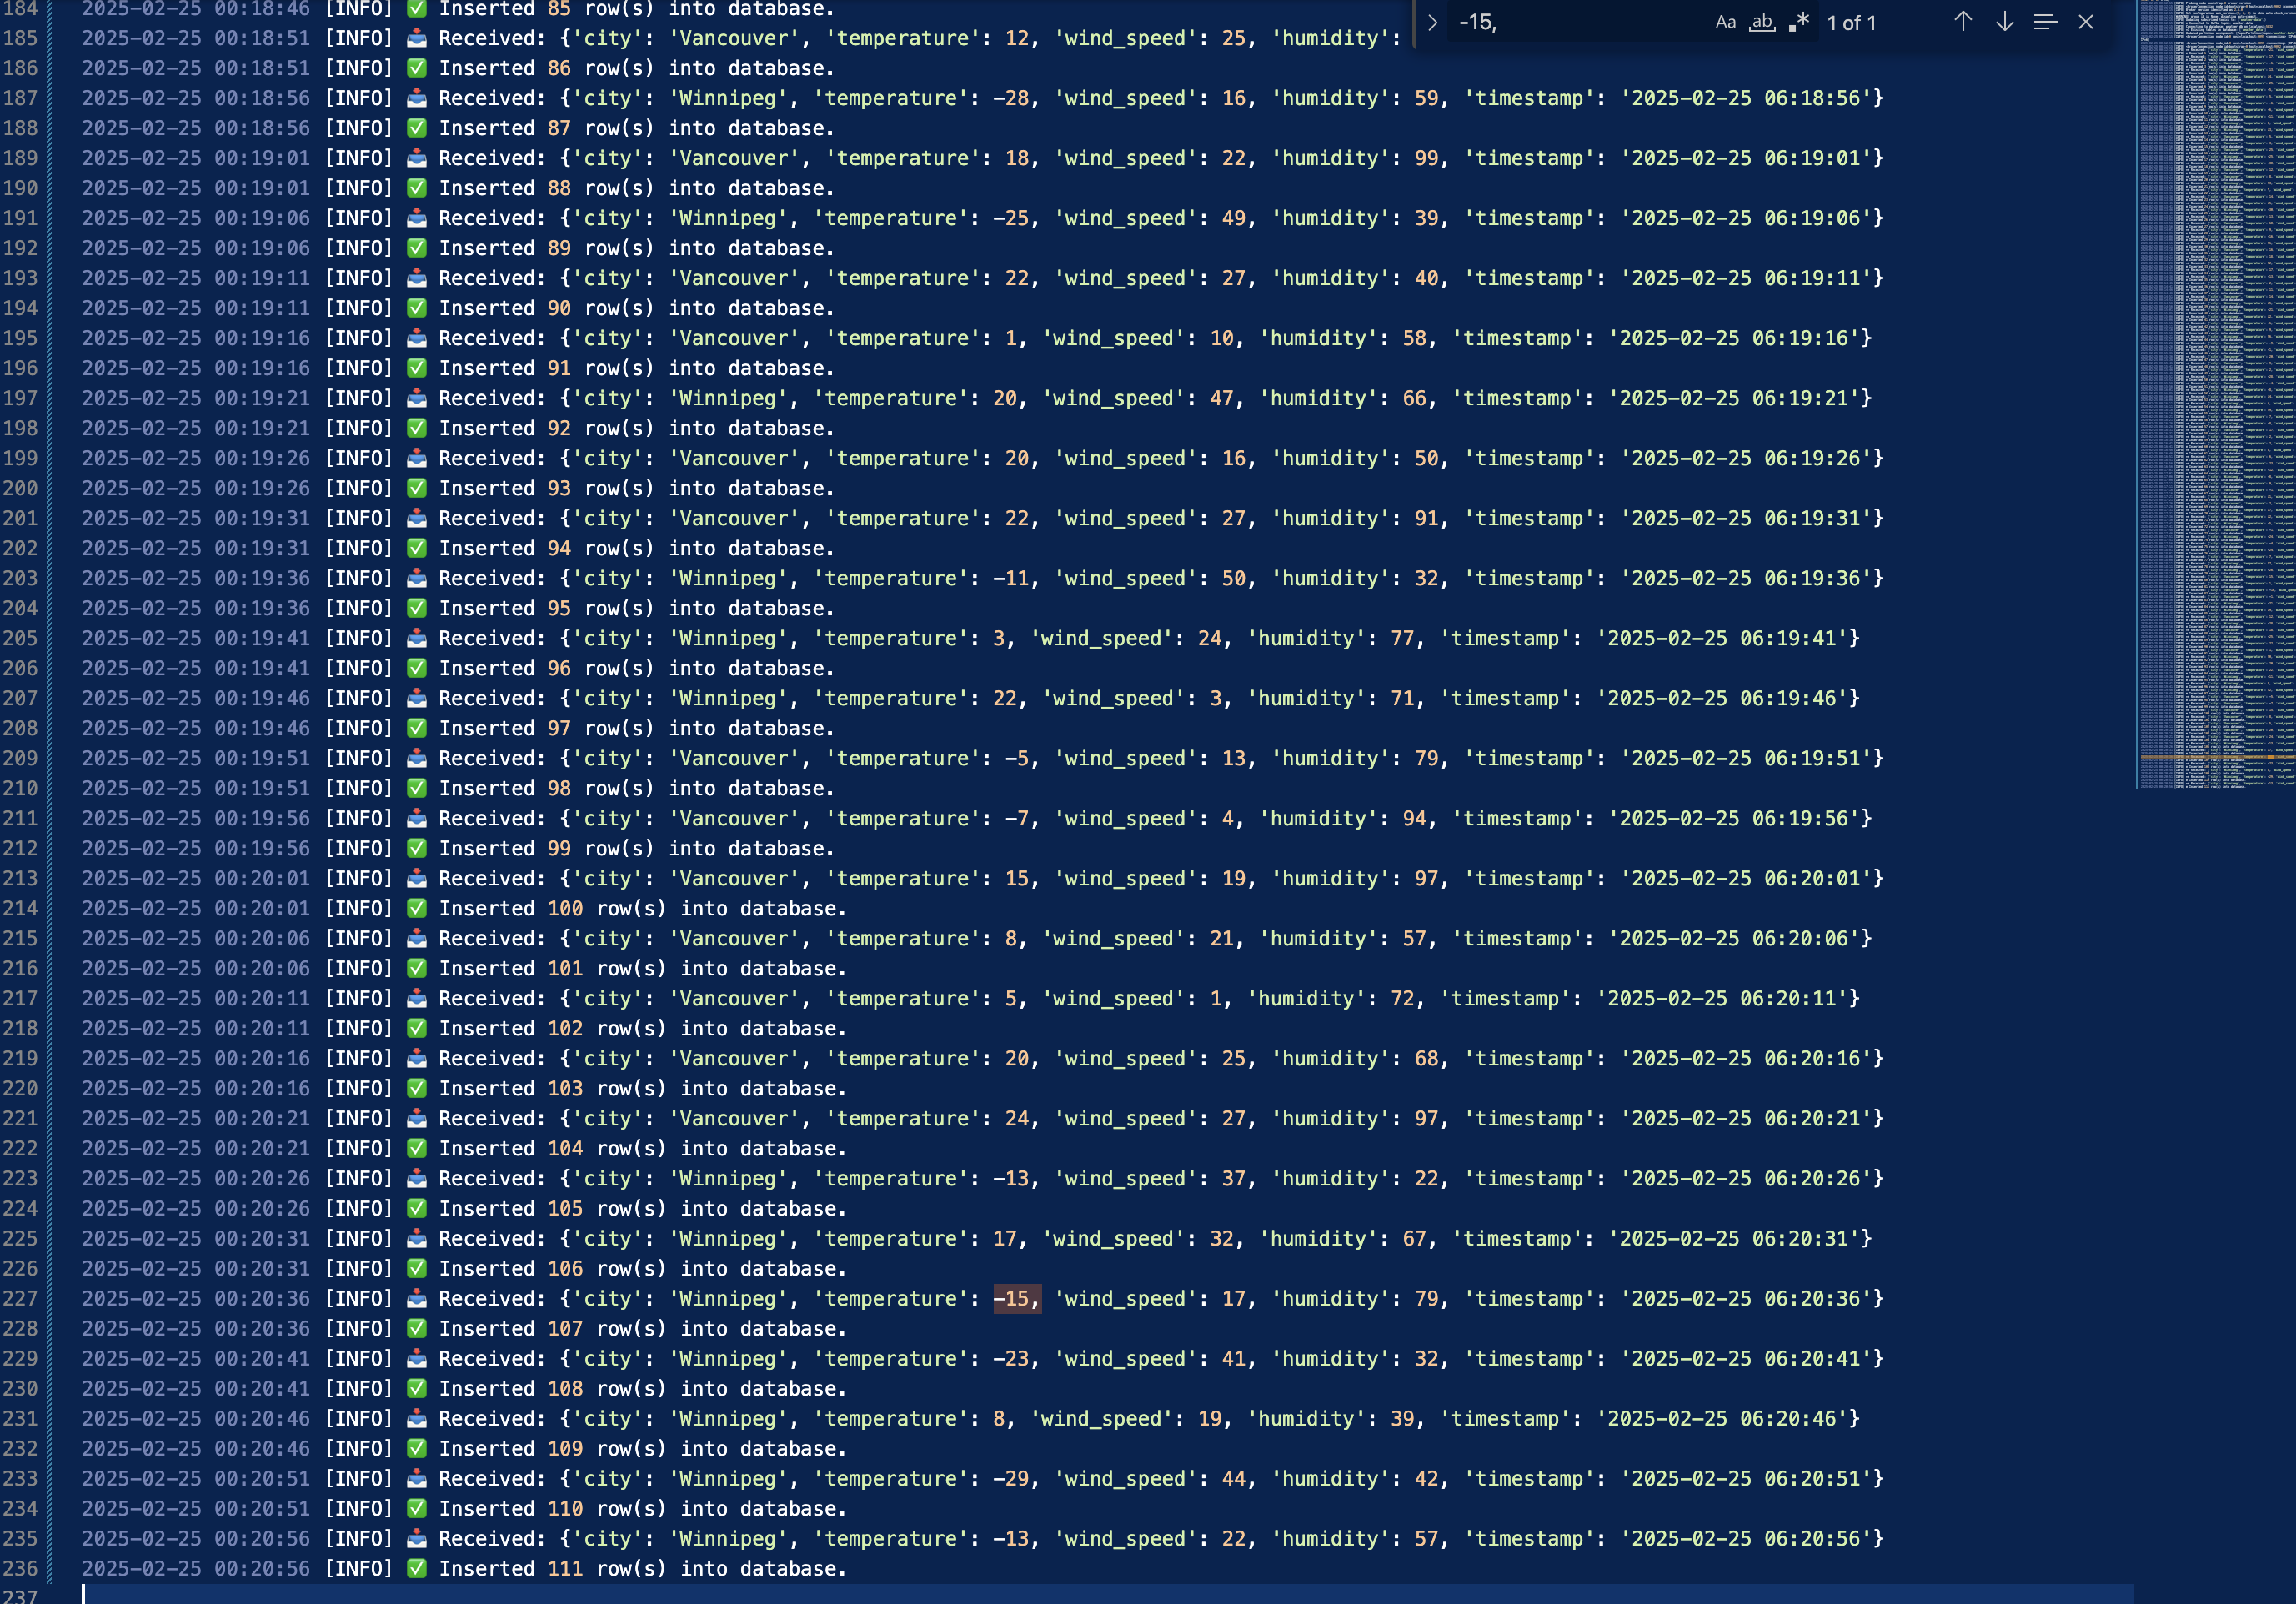

In [35]:
# Showing consumer after closed producer
display(Image(filename="screenshots/consumer_logs.png"))

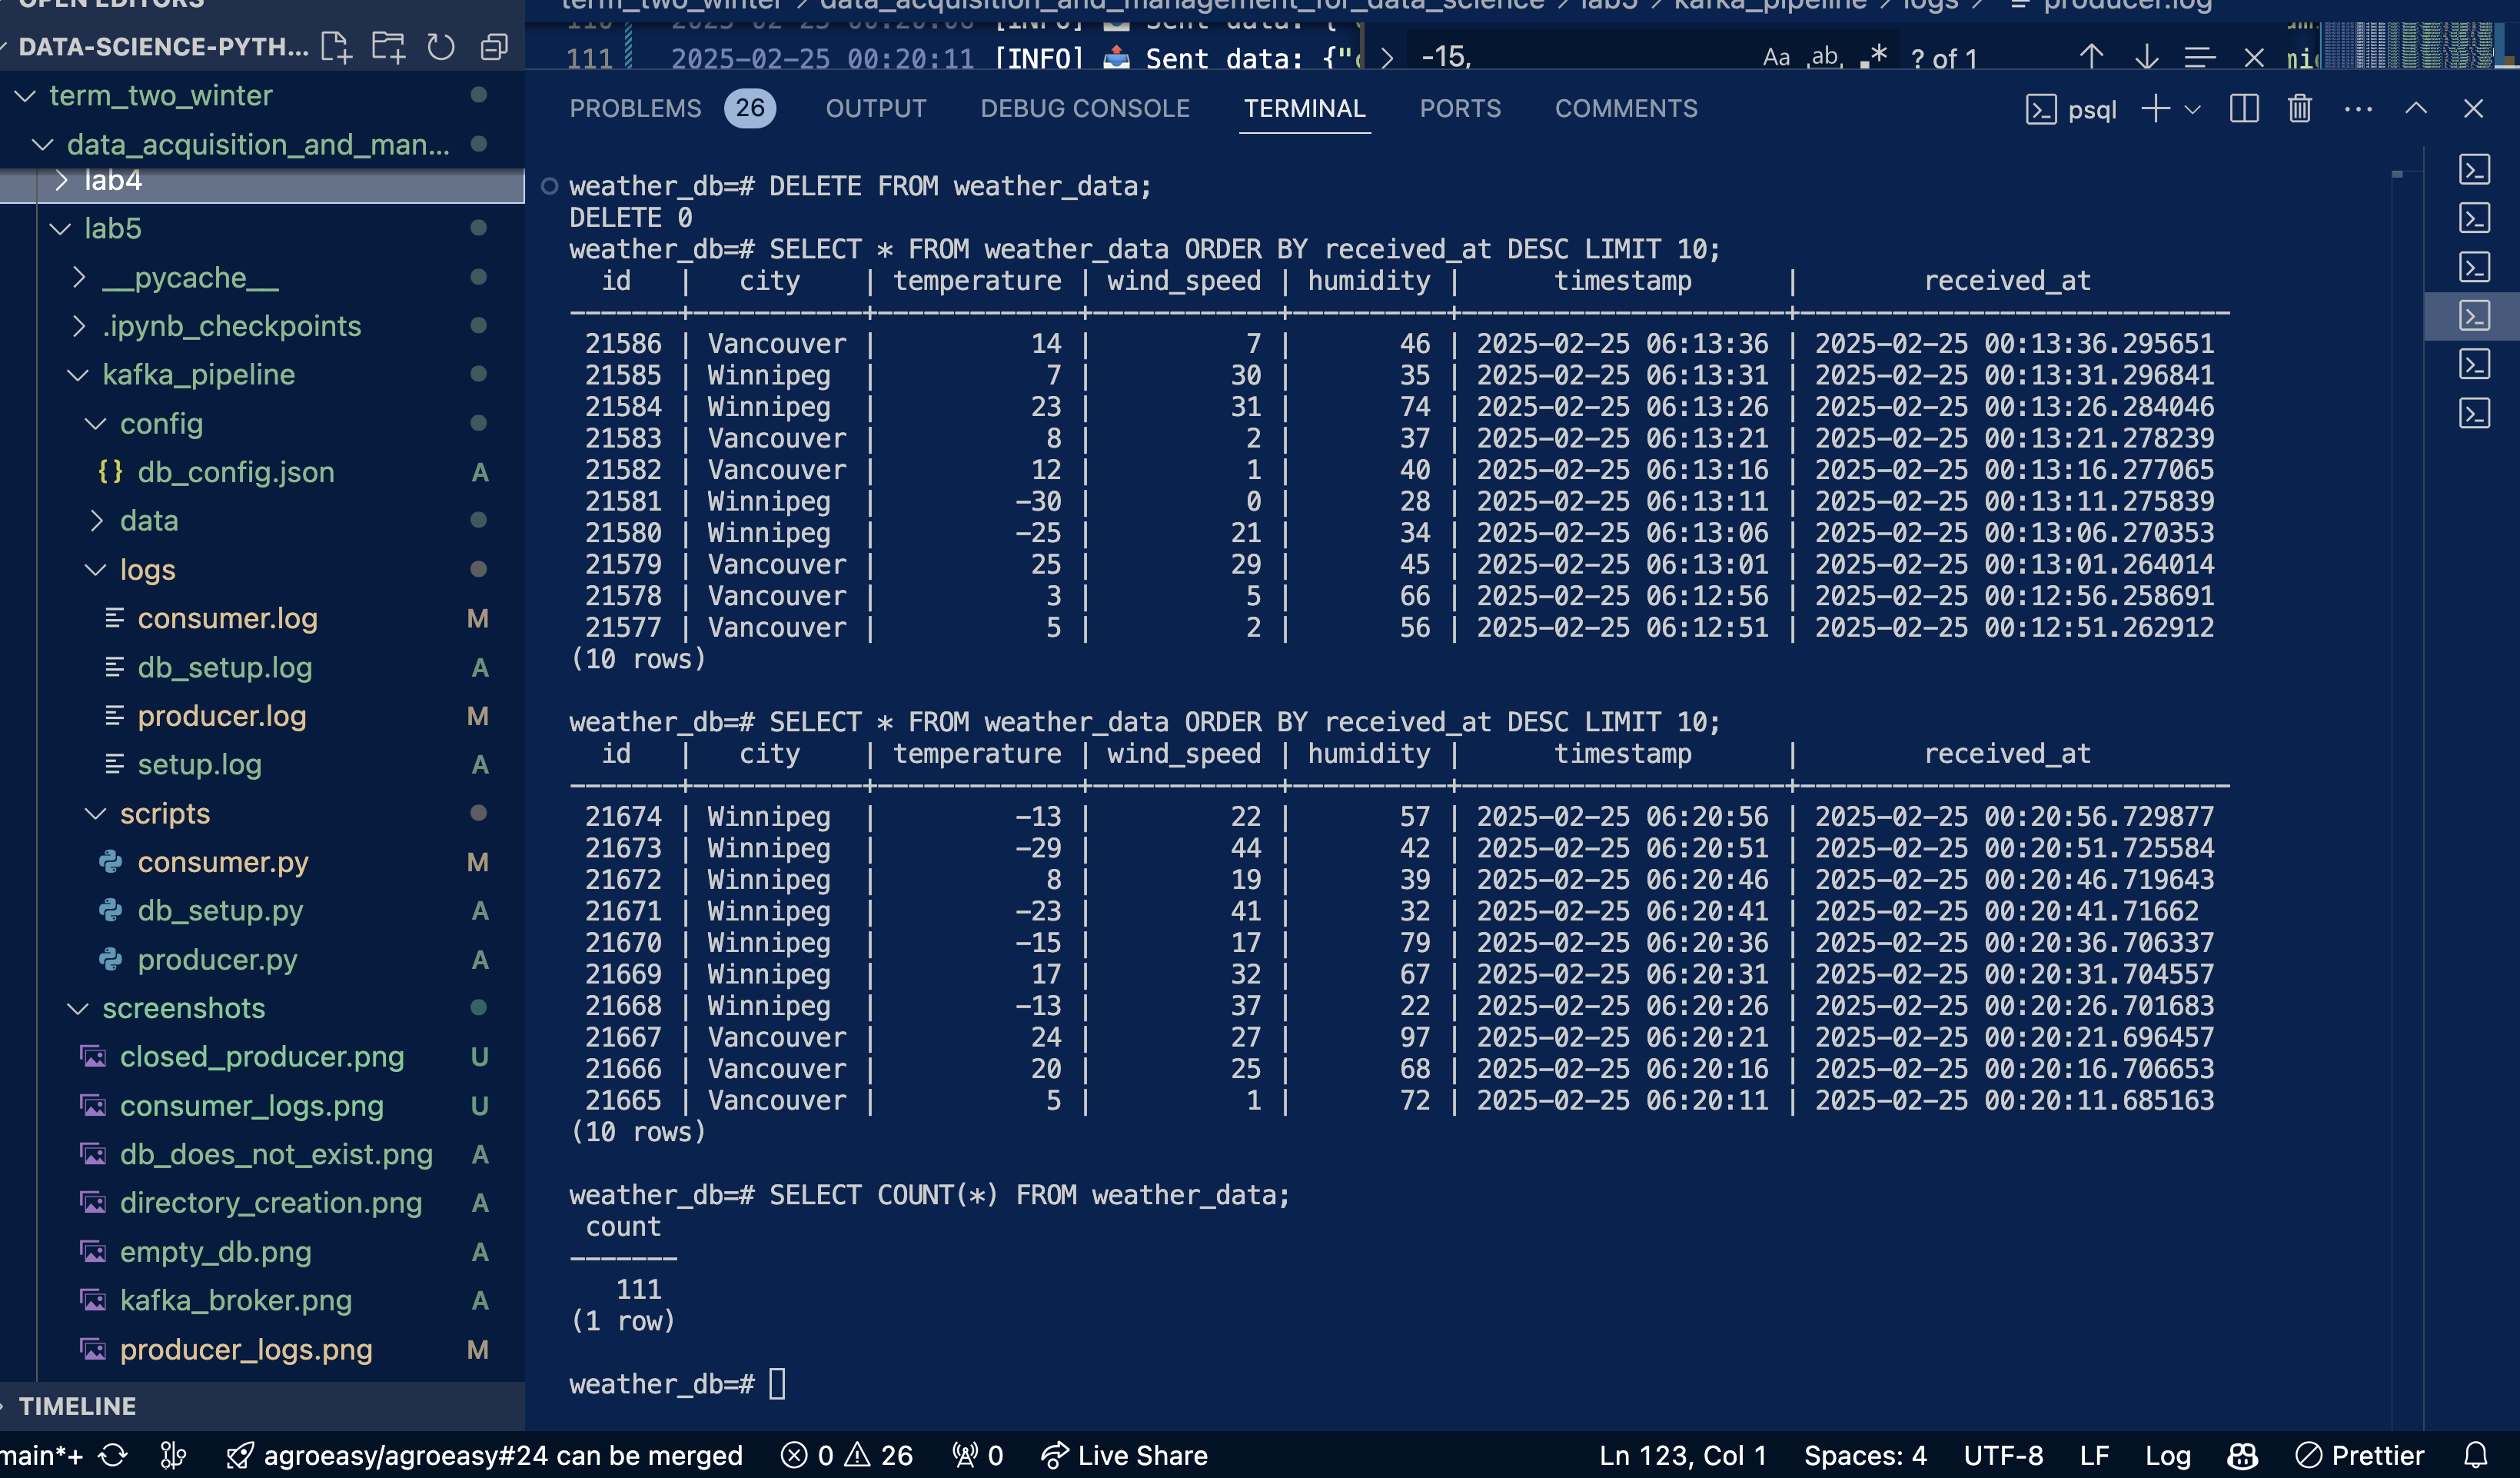

In [36]:
# Data count confirmation on db
display(Image(filename="screenshots/db_logs.png"))

## Outcome
All flow the steps below tested and validated
- I successfully ran the zookeeper service in a terminal.
- I successfully ran the kafka service in another terminal.
- I created a topic and a producer in a third terminal
- I ran my subscriber in a 4th terminal
- I stopped producer in almost 10 minutes
- I verified data is loaded onto the database.
- I stopped all services.

### **📌 Conclusion**  

This project successfully implemented a **Kafka-based data streaming pipeline** for real-time weather data processing using **Apache Kafka, Python, and PostgreSQL**. The pipeline was designed to **simulate live weather data** for two Canadian cities—Winnipeg and Vancouver—by generating synthetic temperature, wind speed, and humidity values and streaming them to a Kafka topic (`weather-data`).  

#### **🔹 Key Achievements**  
✅ **Automated Data Streaming**: The **Kafka producer** successfully generated and published weather data every five seconds.  
✅ **Efficient Data Processing**: The **Kafka consumer** effectively consumed messages, appended a timestamp, and stored the data in a PostgreSQL database.  
✅ **Database Integration**: A structured table (`weather_data`) was created to store and manage incoming records efficiently.  
✅ **Error Handling & Logging**: The system logged **all key events**, including message transmission, database insertions, and failure scenarios, ensuring traceability.  
✅ **Testing & Validation**: The producer and consumer were tested to ensure they handled real-time data correctly, and database queries confirmed **data consistency** without duplication.  

#### **🔹 Challenges Faced & Lessons Learned**  
🚧 **Kafka Setup & Connectivity Issues**: Initially, the producer and consumer had connection failures, requiring a proper configuration of the Kafka broker and topics.  
🚧 **Timestamp Format Mismatch**: The timestamp format caused insertion errors in PostgreSQL, necessitating a fix in the producer to ensure compatibility.  
🚧 **Duplicate & Old Messages**: Since the consumer reads from the beginning (`auto_offset_reset="earliest"`), old messages persisted, requiring **topic cleanup** to reset offsets.  
🚧 **Handling Failures Gracefully**: We implemented **retries** and **graceful exits** to handle network failures and database disconnections without system crashes.  

#### **🔹 Future Improvements**  
🚀 **Scalability Enhancements**: The system can be expanded to handle multiple Kafka partitions and consumers for better load distribution.  
🚀 **Schema Evolution**: Using **Apache Avro** or **Protobuf** for message serialization would enhance compatibility with future schema changes.  
🚀 **Cloud Integration**: Deploying the pipeline on **AWS MSK (Managed Kafka)** or **Google Cloud Pub/Sub** would improve reliability and scalability.  
🚀 **Visualization & Dashboards**: Integrating with tools like **Grafana** or **Tableau** can enable real-time weather monitoring and insights.  

### **🔹 Final Thoughts**  
This project provided hands-on experience in **real-time data streaming, message brokering, and database integration**, simulating real-world **data engineering workflows**. The **Kafka-based architecture** ensures **fault tolerance, scalability, and efficiency**, making it a valuable approach for high-velocity data pipelines.  

With this foundation, we can now extend the project to handle **more cities, additional weather parameters, and advanced analytics**, demonstrating Kafka’s potential in handling live streaming data for various applications. 🚀🌍📊

In [ ]:
# open file in nano command nano ETL_script.sh

display(Image(filename="screenshots/code_open_command.png"))